In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [2]:
url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/" \
      "master/csse_covid_19_data/csse_covid_19_time_series/" \
      "time_series_covid19_confirmed_global.csv"

df = pd.read_csv(url)
df.head()


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Columns: 1147 entries, Province/State to 3/9/23
dtypes: float64(2), int64(1143), object(2)
memory usage: 2.5+ MB


In [4]:
df.describe()


,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
count,287.000000,287.000000,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000,...,2.890000e+02,2.890000e+02,2.890000e+02,2.890000e+02,2.890000e+02,2.890000e+02,2.890000e+02,2.890000e+02,2.890000e+02,2.890000e+02
mean,19.718719,22.182084,1.927336,2.273356,3.266436,4.972318,7.335640,10.134948,19.307958,21.346021,...,2.336755e+06,2.337519e+06,2.338173e+06,2.338805e+06,2.338992e+06,2.339187e+06,2.339387e+06,2.339839e+06,2.340460e+06,2.341073e+06
std,25.956609,77.870931,26.173664,26.270191,32.707271,45.523871,63.623197,85.724481,210.329649,211.628535,...,8.506608e+06,8.511285e+06,8.514488e+06,8.518031e+06,8.518408e+06,8.518645e+06,8.519346e+06,8.521641e+06,8.524968e+06,8.527765e+06
min,-71.949900,-178.116500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.072192,-32.823050,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.456700e+04,1.456700e+04,1.456700e+04,1.456700e+04,1.456700e+04,1.456700e+04,1.456700e+04,1.456700e+04,1.456700e+04,1.456700e+04
50%,21.512583,20.939400,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.032480e+05,1.032480e+05,1.032480e+05,1.032480e+05,1.032480e+05,1.032480e+05,1.032480e+05,1.032480e+05,1.032480e+05,1.032480e+05
75%,40.401784,89.224350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.051998e+06,1.052122e+06,1.052247e+06,1.052382e+06,1.052519e+06,1.052664e+06,1.052664e+06,1.052926e+06,1.053068e+06,1.053213e+06
max,71.706900,178.065000,444.000000,444.000000,549.000000,761.000000,1058.000000,1423.000000,3554.000000,3554.000000,...,1.034435e+08,1.035339e+08,1.035898e+08,1.036487e+08,1.036508e+08,1.036470e+08,1.036555e+08,1.036909e+08,1.037558e+08,1.038027e+08


In [5]:
df.isnull().sum()


,0
Province/State,198
Country/Region,0
Lat,2
Long,2
1/22/20,0
...,...
3/5/23,0
3/6/23,0
3/7/23,0
3/8/23,0


In [6]:
df_long = df.melt(
    id_vars=["Province/State", "Country/Region", "Lat", "Long"],
    var_name="Date",
    value_name="Confirmed"
)

df_long["Date"] = pd.to_datetime(df_long["Date"])
df_long.head()


/tmp/ipython-input-3830617554.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_long["Date"] = pd.to_datetime(df_long["Date"])


,Province/State,Country/Region,Lat,Long,Date,Confirmed
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0
1,NaN,Albania,41.15330,20.168300,2020-01-22,0
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0


In [7]:
country_df = df_long.groupby(
    ["Country/Region", "Date"]
)["Confirmed"].sum().reset_index()

country_df.head()


,Country/Region,Date,Confirmed
0,Afghanistan,2020-01-22,0
1,Afghanistan,2020-01-23,0
2,Afghanistan,2020-01-24,0
3,Afghanistan,2020-01-25,0
4,Afghanistan,2020-01-26,0


In [8]:
country_df["Daily_Cases"] = country_df.groupby(
    "Country/Region"
)["Confirmed"].diff()

country_df["Weekly_Avg"] = (
    country_df.groupby("Country/Region")["Daily_Cases"]
    .rolling(7)
    .mean()
    .reset_index(level=0, drop=True)
)


In [9]:
countries = ["India", "US", "Italy"]
plot_df = country_df[country_df["Country/Region"].isin(countries)]


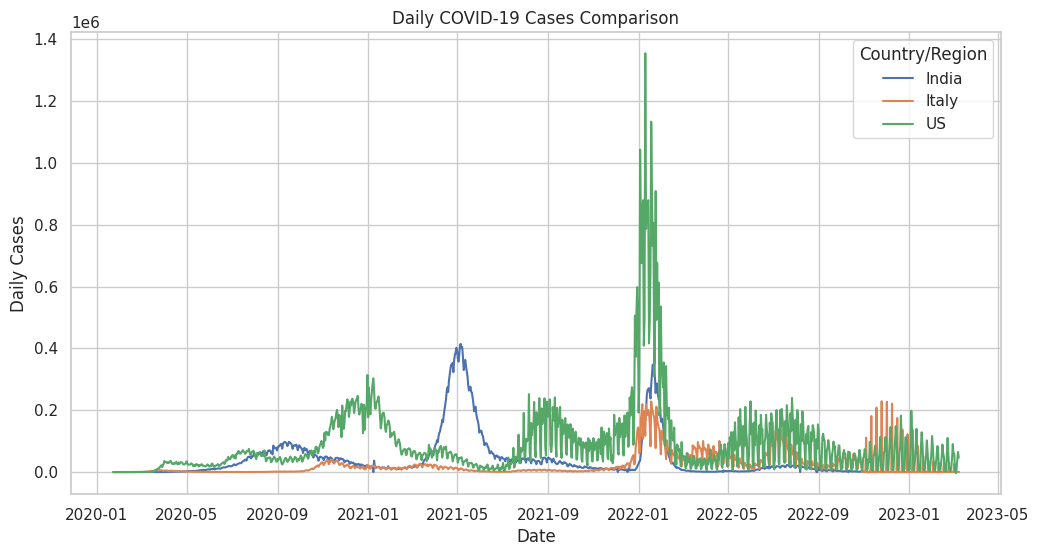

In [10]:
plt.figure(figsize=(12,6))
sns.lineplot(data=plot_df, x="Date", y="Daily_Cases", hue="Country/Region")
plt.title("Daily COVID-19 Cases Comparison")
plt.xlabel("Date")
plt.ylabel("Daily Cases")
plt.show()


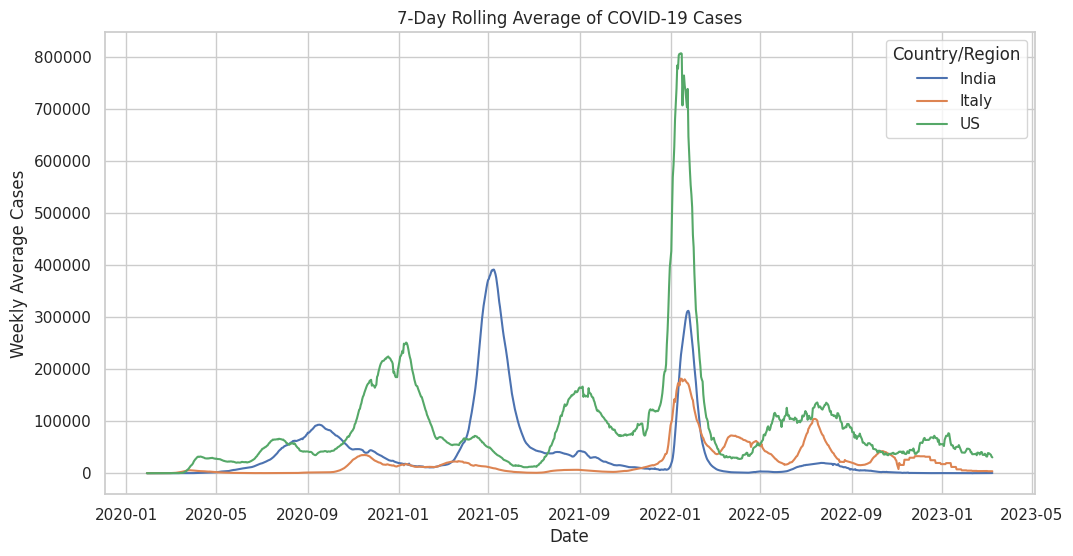

In [11]:
plt.figure(figsize=(12,6))
sns.lineplot(data=plot_df, x="Date", y="Weekly_Avg", hue="Country/Region")
plt.title("7-Day Rolling Average of COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("Weekly Average Cases")
plt.show()


In [12]:
peak_cases = plot_df.groupby("Country/Region")["Daily_Cases"].max()
peak_cases


,Daily_Cases
Country/Region,
India,414188.0
Italy,229122.0
US,1354505.0


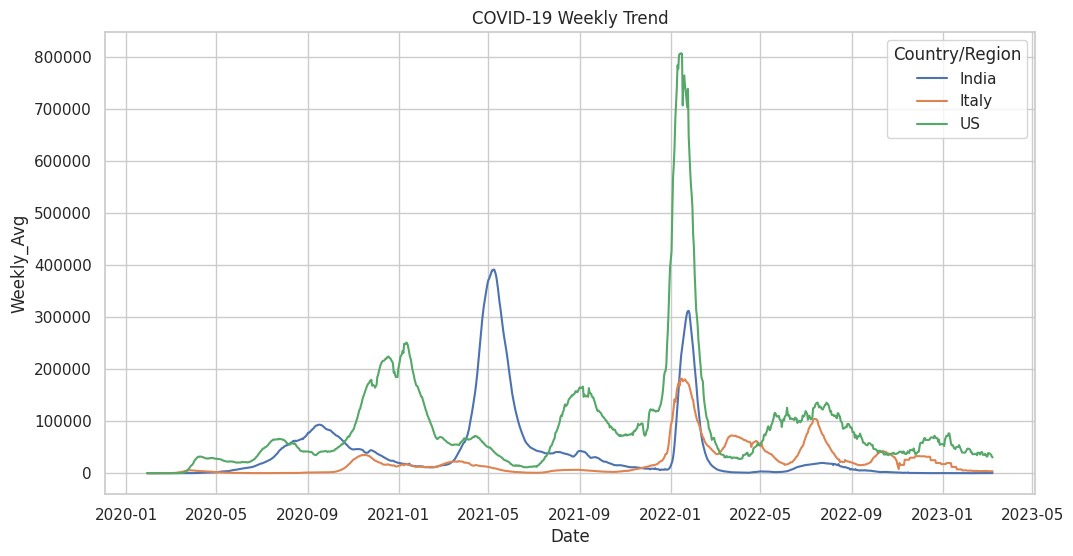

In [13]:
plt.figure(figsize=(12,6))
sns.lineplot(data=plot_df, x="Date", y="Weekly_Avg", hue="Country/Region")
plt.title("COVID-19 Weekly Trend")
plt.savefig("covid_trend.png", dpi=300)
plt.show()


### Key Insights:
- The US experienced the highest peak daily COVID-19 cases.
- India showed multiple waves with gradual increases.
- Italy had early sharp spikes followed by stabilization.
- 7-day rolling averages reduce noise and highlight true trends.
- Country comparison shows different pandemic patterns.
